In [4]:
import os 
import scb_multiome as scbm 
import scanpy as sc 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 


2025-06-01 16:53:49.027401: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.41). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [5]:
BASE_DIR = "/mnt/fxcai/nfs_share2"
data_dir = "../../data"
atac_path = f"{data_dir}/atac_data/ad_atac_132k.h5ad"
rna_path = f"{data_dir}/rna_data/tfs.h5ad"
preprocess_folder_acc = f"{data_dir}/atac_data/scb_processed"
preprocess_folder_rna = f"{data_dir}/rna_data"
chippath = f"{data_dir}/chip_data/atac_132k_encode_byTF.csv"
gt_path = f"{data_dir}/chip_data/blood_gt.csv"
fimo_dir = f"{data_dir}/all_seq_match/fimo_res.csv"
spearmanr_dir = f"{data_dir}/spearmanR/SpearmanR.csv"

result_dir = "."

### read groundtruth, baseline metrics & model metrics

In [6]:
ad_atac = sc.read_h5ad(atac_path)
ad_rna = sc.read_h5ad(rna_path)
sc.pp.scale(ad_rna)

chip_bulk = pd.read_csv(chippath, index_col=0)
df_gt = pd.read_csv(gt_path, index_col=0)
act_pval = pd.read_csv(fimo_dir, index_col=0)
celltype_specific_SpearmanR = pd.read_csv(spearmanr_dir, index_col=0)

## !! keep the same jaspar_motifs.index for writing gradSeq/gradTF
tfs_cts = df_gt.columns
jaspar_motifs = scbm.pp.read_JASPAR_pwms(f"{BASE_DIR}/genomes/JASPAR_human_TFs_meme/20230424043428_JASPAR2022_combined_matrices_2028_meme.txt")
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna.var['gene_symbols'])]
jaspar_motifs = jaspar_motifs.reset_index(drop=True)
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin([tf_ct.split("_")[0] for tf_ct in tfs_cts])]

In [7]:
peak_emb = pd.read_csv("./benchmark_summarize/peak_emb.csv", index_col=0)

In [8]:
## consistent with writing gradSeq/gradTF, subset peaks to >=10% acc for faster computation
print(ad_atac.shape)
peaks_select = ad_atac.var['n_cells']>0.1*ad_atac.n_obs
ad_atac = ad_atac[:, peaks_select]
print(ad_atac.shape)

celltype_specific_SpearmanR = celltype_specific_SpearmanR.loc[peaks_select,:]
act_pval = act_pval.loc[peaks_select,:]
df_gt = df_gt.loc[peaks_select,:]
chip_bulk = chip_bulk.loc[peaks_select,:]
peak_emb = peak_emb.loc[peaks_select,:]

print(celltype_specific_SpearmanR.shape, act_pval.shape, df_gt.shape, chip_bulk.shape, peak_emb.shape)

(9543, 131511)
(9543, 20889)
(20889, 13) (20889, 14) (20889, 13) (20889, 870) (20889, 32)


In [9]:
## filter out TFs without available encode data 
tfs_gt = df_gt.columns.str.split("_").str[0]
df_gt = df_gt.loc[:,tfs_gt.isin(chip_bulk.columns)]
print(df_gt.shape)

(20889, 11)


In [ ]:
gradSeq, gradTF = scbm.utils.read_grads_celltype(tfs_cts=df_gt.columns, 
                                                 jaspar_motifs=jaspar_motifs,
                                                 ad_atac=ad_atac,
                                                 ad_rna=ad_rna,
                                                 _chunk_size=50)

CTCF MA1930.1


  0%|          | 0/418 [00:00<?, ?it/s]

100%|██████████| 418/418 [00:37<00:00, 11.01it/s]


classical monocytes: 1848
naive B cells: 282
CTCF MA0139.1


100%|██████████| 418/418 [00:37<00:00, 11.05it/s]


...

classical monocytes: 1848
STAT1 MA0517.1


100%|██████████| 418/418 [00:32<00:00, 13.01it/s]


classical monocytes: 1848
STAT1 MA0137.3


100%|██████████| 418/418 [00:32<00:00, 13.02it/s]


classical monocytes: 1848


In [7]:
gradSeq.to_csv("./benchmark_summarize/gradSeq_ct_specific.csv")
gradTF.to_csv("./benchmark_summarize/gradTF_ct_specific.csv")

In [7]:
gradSeq = pd.read_csv("./benchmark_summarize/gradSeq_ct_specific.csv", index_col=0)
gradTF = pd.read_csv("./benchmark_summarize/gradTF_ct_specific.csv", index_col=0)

### 1. baseline, model, extended (35) metrics, train on 1% groundtruths 

In [8]:
bm_baseline = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_baseline.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_baseline_on_gt = bm_baseline.auprcs_to_csv()
auprc_baseline_on_gt.index = ['baseline_on_gt']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 42.48it/s]


In [9]:
bm_std= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=None)
bm_std.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_std_on_gt = bm_std.auprcs_to_csv()
auprc_std_on_gt.index = ['std_on_gt']

100%|██████████| 11/11 [00:00<00:00, 28.88it/s]


In [10]:
bm_extended = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_extended.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_ext_on_gt = bm_extended.auprcs_to_csv()
auprc_ext_on_gt.index = ['ext_on_gt']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:02<00:00,  5.01it/s]


### 2. baseline, model (4), extended (35) metrics, train on non-tissue specific chip data


In [11]:
bm_baseline_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=chip_bulk)
bm_baseline_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_baseline_on_bulk = bm_baseline_noisy.auprcs_to_csv()
auprc_baseline_on_bulk.index = ['baseline_on_bulk']


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 15.68it/s]


In [12]:
bm_std_noisy= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=chip_bulk)
bm_std_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_std_on_bulk = bm_std_noisy.auprcs_to_csv()
auprc_std_on_bulk.index = ['std_on_bulk']


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:01<00:00,  8.90it/s]


In [13]:
bm_extended_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                jaspar_motifs=jaspar_motifs,
                                chip_bulk=chip_bulk)
bm_extended_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_ext_on_bulk = bm_extended_noisy.auprcs_to_csv()
auprc_ext_on_bulk.index = ['ext_on_bulk']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:10<00:00,  1.06it/s]


### 3. gradTF*gradSeq. Groundtruth used to determine cutoff only


In [14]:
## match gradTF columns to gradSeq
gradTF_expand = pd.DataFrame(
    {tf_mm_ct : gradTF[f"{tf_mm_ct.split('_')[0].split(':')[0]}_{tf_mm_ct.split('_')[1]}"] 
     for tf_mm_ct in gradSeq.columns}
    )

bm_refless = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[gradTF_expand*gradSeq],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_refless.logReg_all(downsample_frac=1., trainOn="gt")
auprc_refless = bm_refless.auprcs_to_csv()
auprc_refless.index = ['grad_mult']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 42.43it/s]


#### tidy auprcs result & visialize 

In [15]:
res = pd.concat([auprc_baseline_on_gt, auprc_std_on_gt, auprc_ext_on_gt,
                 auprc_baseline_on_bulk, auprc_std_on_bulk, auprc_ext_on_bulk,
                 auprc_refless]).T
res[:5]

,baseline_on_gt,std_on_gt,ext_on_gt,baseline_on_bulk,std_on_bulk,ext_on_bulk,grad_mult
CTCF:MA1930.1_classical monocytes,0.537170,0.501792,0.423096,0.555306,0.505570,0.437425,0.396164
CTCF:MA0139.1_classical monocytes,0.695143,0.663194,0.524833,0.681399,0.576456,0.467558,0.399344
CTCF:MA1929.1_classical monocytes,0.590588,0.571890,0.486690,0.587320,0.528980,0.440887,0.395027
CTCF:MA1930.1_naive B cells,0.588069,0.591532,0.514929,0.593917,0.572927,0.535442,0.502115
CTCF:MA0139.1_naive B cells,0.709125,0.713045,0.606137,0.680813,0.644769,0.562446,0.507286


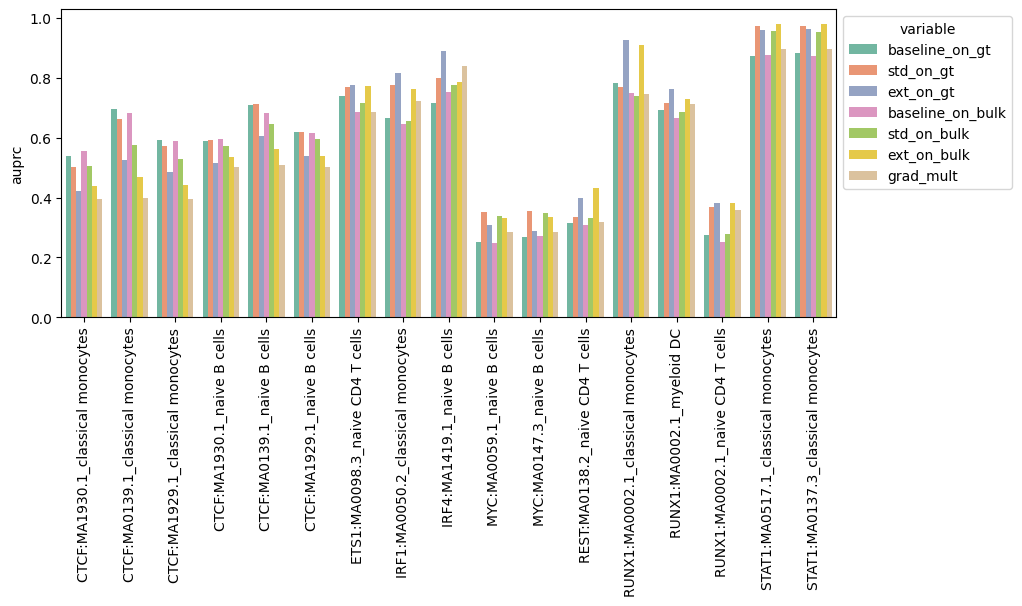

In [16]:
res['tf:mm_ct'] = res.index
res_plot = res.melt(
            value_vars=[c for c in res.columns if c != "tf:mm_ct"], 
            id_vars=['tf:mm_ct'])
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=res_plot, x = "tf:mm_ct", y="value", hue='variable', palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("auprc")
ax.tick_params(axis='x', rotation=90)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [17]:
fig.savefig("./figs/auprcs.svg", dpi=300, bbox_inches='tight')

## shortcut to collapse cell dimension for gradTF & gradSeq
The above benchmark is only on a subset of peaks because the full gradSeq & gradTF are too large (n_peak=131511, n_cell=9543, n_tf=322). 

To benchmark on all peaks, we take mean TF expression (ie, n_cell=1) for speedup, but the value will be different. 

In [10]:
import json 
import pickle5 
import h5py 

In [11]:
ad_atac = sc.read_h5ad(atac_path)
ad_rna = sc.read_h5ad(rna_path)
sc.pp.scale(ad_rna)

chip_bulk = pd.read_csv(chippath, index_col=0)
df_gt = pd.read_csv(gt_path, index_col=0)
act_pval = pd.read_csv(fimo_dir, index_col=0)
celltype_specific_SpearmanR = pd.read_csv(spearmanr_dir, index_col=0)

tfs_cts = df_gt.columns
jaspar_motifs = scbm.pp.read_JASPAR_pwms(f"{BASE_DIR}/genomes/JASPAR_human_TFs_meme/20230424043428_JASPAR2022_combined_matrices_2028_meme.txt")
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna.var['gene_symbols'])]
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin([tf_ct.split("_")[0] for tf_ct in tfs_cts])]
### reindex for writing grads below  
jaspar_motifs = jaspar_motifs.reset_index(drop=True)

peak_emb = pd.read_csv("./benchmark_summarize/peak_emb.csv", index_col=0)

In [12]:
## filter out TFs without available encode data 
tfs_gt = df_gt.columns.str.split("_").str[0]
df_gt = df_gt.loc[:,tfs_gt.isin(chip_bulk.columns)]
print(df_gt.shape)

(131511, 11)


#### gradTF & gradSeq for all peaks 

In [5]:
with open(f"{result_dir}/config.json") as f:
    config_d = json.load(f)
    
model = scbm.core.scb_TFs.Model(preprocess_folder_acc = preprocess_folder_acc,
                                preprocess_folder_rna=preprocess_folder_rna,
                                atac = ad_atac.X.T,
                                rna = ad_rna.X,
                                model_config=config_d['model_config']
                                )
model.create_model()
all_ds = model.read_accrna_ds(ds_key='all')

with open(f"{result_dir}/result.pkl", "rb") as handle:
    data = pickle5.load(handle)
model.load_data(data,
                keys = ['params_all',])

In [6]:
cts = df_gt.columns.str.split("_").str[1].unique()

with h5py.File("./benchmark_summarize/grad_allpeak_bycelltype.h5", 'w') as hf:
    grad_tf_gp = hf.create_group('grad_tf',) 
    grad_seq_gp = hf.create_group('grad_seq',) 
    for ct in cts:
        print(ct)
        
        ## subset to cells matching ct        
        cells_select = ad_rna.obs['celltype'] == ct
        ds_in = all_ds.copy()
        ds_in['rna'] = np.mean(all_ds['rna'][cells_select,:], axis=0, keepdims=True)  #(1,n_tf)
        ds_in['atac_dpth'] = np.mean(all_ds['atac_dpth'], keepdims=True) # keep mean
        
        gradtf = scbm.utils.get_grad_tf_small(model=model,
                                            all_ds=ds_in)
        gradtf = np.squeeze(gradtf)
        grad_tf_gp.create_dataset(ct, data=gradtf)
        gradseq = scbm.utils.get_grad_seq_small(model=model, 
                                            all_ds = ds_in,
                                            jaspar_motifs=jaspar_motifs
                                            )
        gradseq = np.squeeze(gradseq)
        grad_seq_gp.create_dataset(ct, data=gradseq)

classical monocytes


100%|██████████| 131511/131511 [01:44<00:00, 1257.41it/s]


max_len=35


100%|██████████| 131511/131511 [03:27<00:00, 632.72it/s]


naive B cells


...

100%|██████████| 131511/131511 [03:23<00:00, 645.41it/s]


myeloid DC


100%|██████████| 131511/131511 [01:41<00:00, 1292.10it/s]


max_len=35


100%|██████████| 131511/131511 [03:27<00:00, 633.70it/s]


#### extract the TFs & motifs in groundtruth & convert to df

In [13]:
gradSeq = pd.DataFrame(index=ad_atac.var_names)
gradTF = pd.DataFrame(index=ad_atac.var_names)
with h5py.File("./benchmark_summarize/grad_allpeak_bycelltype.h5", 'r') as hf:
    for tf_ct in df_gt.columns:
        tf, ct = tf_ct.split("_")[0], tf_ct.split("_")[1]
        tf_idx = np.where(ad_rna.var['gene_symbols'] == tf)[0][0]
        motifs = jaspar_motifs[jaspar_motifs['tf'] == tf]['motif']
        gradSeq[[f"{tf}:{mm}_{ct}" for mm in motifs]] = hf['grad_seq'][ct][:,motifs.index.to_numpy()]
        gradTF[f"{tf}_{ct}"] = hf['grad_tf'][ct][:, tf_idx]

gradSeq[:5]  

,CTCF:MA1930.1_classical monocytes,CTCF:MA0139.1_classical monocytes,CTCF:MA1929.1_classical monocytes,CTCF:MA1930.1_naive B cells,CTCF:MA0139.1_naive B cells,CTCF:MA1929.1_naive B cells,ETS1:MA0098.3_naive CD4 T cells,IRF1:MA0050.2_classical monocytes,IRF4:MA1419.1_naive B cells,MYC:MA0059.1_naive B cells,MYC:MA0147.3_naive B cells,REST:MA0138.2_naive CD4 T cells,RUNX1:MA0002.1_classical monocytes,RUNX1:MA0002.1_myeloid DC,RUNX1:MA0002.1_naive CD4 T cells,STAT1:MA0517.1_classical monocytes,STAT1:MA0137.3_classical monocytes
chr1:9790-10675,0.001711,0.002115,0.001661,0.002241,0.002691,0.002056,0.008606,0.002150,0.003410,0.003002,0.003468,0.003008,0.002167,0.002041,0.005245,0.002464,0.002268
chr1:180599-181702,0.004528,0.004601,0.004261,0.003866,0.003685,0.003805,0.007011,0.005119,0.005234,0.004902,0.005356,0.007008,0.004772,0.004826,0.006569,0.005177,0.003792
chr1:191168-192093,0.006123,0.006851,0.005791,0.001270,0.001683,0.001312,0.002964,0.006397,0.001829,0.001621,0.001761,0.003395,0.007710,0.007694,0.002363,0.007126,0.006989
chr1:267565-268455,0.010384,0.013817,0.010742,0.003584,0.004097,0.003815,0.005638,0.009491,0.004581,0.005554,0.005520,0.004684,0.012070,0.009544,0.004948,0.009972,0.009132
chr1:270876-271770,0.006207,0.006134,0.005978,0.000848,0.000813,0.000809,0.000780,0.008560,0.001009,0.000737,0.000798,0.000640,0.008400,0.006458,0.000787,0.008881,0.010727


### benchmark as above

In [14]:
bm_baseline = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_baseline.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_baseline_on_gt = bm_baseline.auprcs_to_csv()
auprc_baseline_on_gt.index = ['baseline_on_gt']

100%|██████████| 11/11 [00:00<00:00, 12.69it/s]


In [15]:
bm_std= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=None)
bm_std.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_std_on_gt = bm_std.auprcs_to_csv()
auprc_std_on_gt.index = ['std_on_gt']

100%|██████████| 11/11 [00:01<00:00,  9.12it/s]


In [16]:
bm_extended = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_extended.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_ext_on_gt = bm_extended.auprcs_to_csv()
auprc_ext_on_gt.index = ['ext_on_gt']

100%|██████████| 11/11 [00:03<00:00,  3.11it/s]


In [17]:
bm_baseline_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=chip_bulk)
bm_baseline_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_baseline_on_bulk = bm_baseline_noisy.auprcs_to_csv()
auprc_baseline_on_bulk.index = ['baseline_on_bulk']


100%|██████████| 11/11 [00:02<00:00,  3.82it/s]


In [18]:
bm_std_noisy= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=chip_bulk)
bm_std_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_std_on_bulk = bm_std_noisy.auprcs_to_csv()
auprc_std_on_bulk.index = ['std_on_bulk']


100%|██████████| 11/11 [00:04<00:00,  2.45it/s]


In [19]:
bm_extended_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                jaspar_motifs=jaspar_motifs,
                                chip_bulk=chip_bulk)
bm_extended_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_ext_on_bulk = bm_extended_noisy.auprcs_to_csv()
auprc_ext_on_bulk.index = ['ext_on_bulk']

100%|██████████| 11/11 [01:09<00:00,  6.31s/it]


In [20]:
gradTF_expand = pd.DataFrame(
    {tf_mm_ct : gradTF[f"{tf_mm_ct.split('_')[0].split(':')[0]}_{tf_mm_ct.split('_')[1]}"] 
     for tf_mm_ct in gradSeq.columns}
    )

bm_refless = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[gradTF_expand*gradSeq],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_refless.logReg_all(downsample_frac=1., trainOn="gt")
auprc_refless = bm_refless.auprcs_to_csv()
auprc_refless.index = ['grad_mult']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:01<00:00,  8.79it/s]


In [27]:
res = pd.concat([auprc_baseline_on_gt, auprc_std_on_gt, auprc_ext_on_gt,
                 auprc_baseline_on_bulk, auprc_std_on_bulk, auprc_ext_on_bulk,
                 auprc_refless]).T


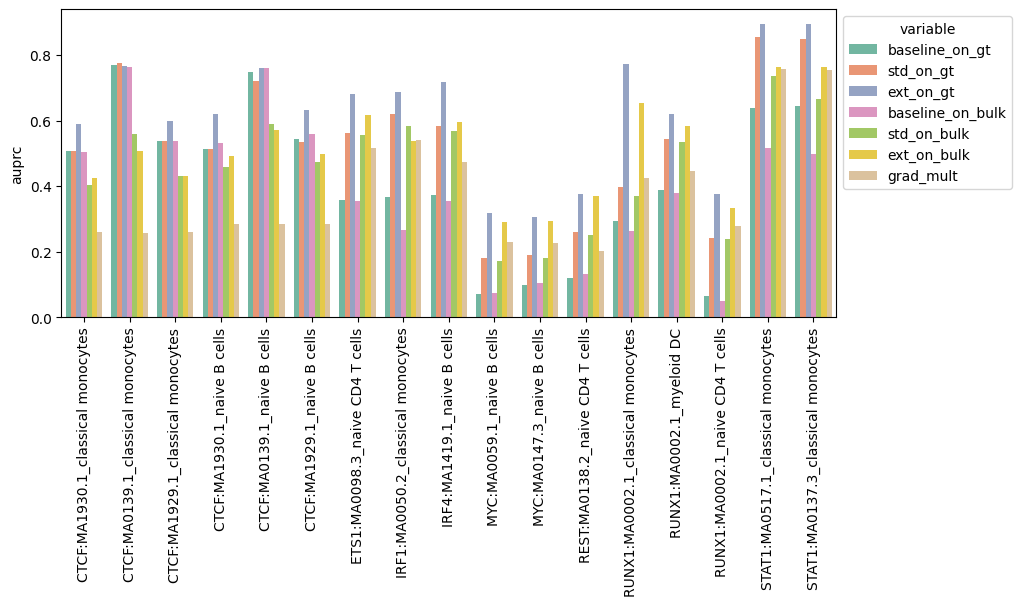

In [28]:
res['tf:mm_ct'] = res.index
res_plot = res.melt(
            value_vars=[c for c in res.columns if c != "tf:mm_ct"], 
            id_vars=['tf:mm_ct'])
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=res_plot, x = "tf:mm_ct", y="value", hue='variable', palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("auprc")
ax.tick_params(axis='x', rotation=90)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [29]:
fig.savefig("./figs/auprcs_allpeaks.svg", dpi=300, bbox_inches='tight')